In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
from dc.config import CONFIG_DIR
from dc.network.models import DataCentreConfig

from dc.network.builder import Builder
from dc.network.solver import Solver
from hydra import initialize, compose

with initialize(config_path="../config"):
    # config is relative to a module
    cfg = compose(config_name="base_config")
    dc_cfg = DataCentreConfig.from_hydra(cfg)
    # dc_cfg.generation.onsite.ccgt.enabled = False
    dc_cfg.grid_connection.max_capacity_MW = 150



builder = Builder(dc_cfg)
network = builder.build()
solver = Solver(network, dc_cfg.solver)
res = solver.solve()

/tmp/ipykernel_3430/3087716194.py:8: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="../config"):
INFO:dc.network.ppa.profiles:PVLib location_solar PPA farm (-27.47°, 153.03°): tilt=27.5° az=0.0° PR=0.70 | clear-sky yield=2608 MWh/MWp/yr → P50 yield=1825 MWh/MWp/yr | mean CF=0.2084  max CF=0.7421  zero-hours=4329
INFO:dc.network.builder:Network built: 6 buses, 5 generators, 3 links, 1 stores
INFO:dc.network.solver:Solving (snapshots=8736, components: 5G 3L 1S)
/workspaces/Uni/ENN655/dc/dc/network/solver.py:130: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = self.n.optimize(
INFO:linopy.model: Solve p

Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


INFO:gurobipy:Set parameter WLSSecret


...

Set parameter ScaleFlag to value 2


INFO:gurobipy:Set parameter ScaleFlag to value 2


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Debian GNU/Linux 13 (trixie)")
INFO:gurobipy:
INFO:gurobipy:CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:ObjScale  -1
INFO:gurobipy:ScaleFlag  2
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:NumericFocus  3
INFO:gurobipy:
INFO:gurobipy:Academic license 2709657 - for non-commercial use only - registered to n1___@qut.edu.au
INFO:gurobipy:Optimize a model with 279562 rows, 113575 columns and 493632 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0x90357918
INFO:gurobipy:Model has 43684 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [3e-06, 4e+00]
INFO:gurobipy:  Objective range  [3e-03, 3e+05]
INFO:gurobipy:  Bounds range

INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 113575 primals, 279562 duals
Objective: 5.87e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
INFO:dc.network.solver:Solve complete: status=ok, condition=optimal
INFO:dc.network.solver:
══ Data Centre Metrics ═══════════════════════════════════

In [9]:
res.metrics.generation

GenerationMix(grid_mwh=365903.99999999994, ccgt_mwh=512064.0000000002, solar_ppa_mwh=372214.4613135756, wind_ppa_mwh=3071.6925325781312, rooftop_solar_mwh=0.0, battery_net_mwh=0.0, grid_capacity_mw=150.0, ccgt_capacity_mw=114.93212669683261, solar_ppa_capacity_mw=272053.0042289699, wind_ppa_capacity_mw=16.36407701120269, battery_capacity_mwh=0.0)

In [7]:
network.generators_t.p.sum()

name
nem               0.000000e+00
water_supply      7.106953e+05
gas_supply        1.004047e+06
ppa:solar_farm    3.722145e+05
ppa:wind_farm     3.071693e+03
dtype: float64

In [6]:
network.stats.capacity_factor()

component  carrier                 
Generator  Natural Gas                 0.114932
           PPA Solar                   0.000157
           PPA Wind                    0.021487
           Water                       0.081352
Link       Closed Cycle Gas Turbine    1.000000
           Electricity                 0.670000
           Grid Electricity            0.286391
Load       Compute                          NaN
Store      CO2                         0.000007
           Flexible Compute            0.565417
dtype: float64

In [4]:
network.stats.energy_balance.iplot()

<Axes: xlabel='snapshot'>

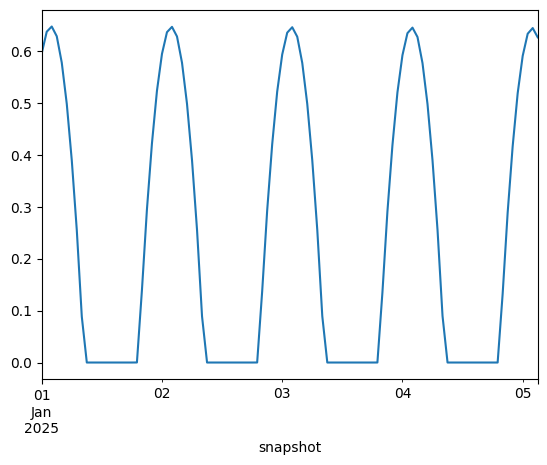

In [6]:
network.links

,bus0,bus1,bus3,bus2,type,carrier,efficiency,efficiency3,efficiency2,active,...,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,delay,delay3,delay2,cyclic_delay,cyclic_delay3,cyclic_delay2,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
grid_connection,grid,facility,,,,grid,0.975000,NaN,NaN,True,...,NaN,NaN,NaN,0,0,0,True,True,True,150.000000
facility_to_compute,facility,compute,,water_supply,,electricity,0.746269,NaN,-0.008955,True,...,NaN,NaN,NaN,0,0,0,True,True,True,150.000000
CCGT,gas_supply,facility,facility_emissions,water_supply,,gas,0.510000,0.014314,-0.700000,True,...,NaN,NaN,NaN,0,0,0,True,True,True,197.058824


In [3]:
network.links

,bus0,bus1,bus3,bus2,type,carrier,efficiency,efficiency3,efficiency2,active,...,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,delay,delay3,delay2,cyclic_delay,cyclic_delay3,cyclic_delay2,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
grid_connection,grid,facility,,,,grid,0.975000,NaN,NaN,True,...,NaN,NaN,NaN,0,0,0,True,True,True,150.000000
facility_to_compute,facility,compute,,water_supply,,electricity,0.746269,NaN,-0.008955,True,...,NaN,NaN,NaN,0,0,0,True,True,True,150.000000
CCGT,gas_supply,facility,facility_emissions,water_supply,,gas,0.510000,0.014314,-0.700000,True,...,NaN,NaN,NaN,0,0,0,True,True,True,197.058824


In [23]:
network.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
nem,grid,Slack,,1000.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,1.000000e+03
water_supply,water_supply,Slack,,0.0,0.0,True,0.0,1.000000e+09,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,1.000000e+09
gas_supply,gas_supply,Slack,,0.0,0.0,True,0.0,1.000000e+09,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,1.000000e+09
ppa:solar_farm,grid,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.000000e+00
ppa:wind_farm,grid,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.000000e+00


In [6]:
network.stats.energy_balance.iplot()

In [23]:
network.generators_t.p

name,nem,water_supply,gas_supply,ppa:solar_farm,ppa:wind_farm
snapshot,,,,,
2025-01-01 00:00:00,0.0,0.9,0.0,0.0,0.0
2025-01-01 01:00:00,0.0,0.9,0.0,0.0,0.0
2025-01-01 02:00:00,0.0,0.9,0.0,0.0,0.0
2025-01-01 03:00:00,0.0,0.9,0.0,0.0,0.0
2025-01-01 04:00:00,0.0,0.9,0.0,0.0,0.0
...,...,...,...,...,...
2025-12-30 19:00:00,0.0,0.9,0.0,0.0,0.0
2025-12-30 20:00:00,0.0,0.9,0.0,0.0,0.0
2025-12-30 21:00:00,0.0,0.9,0.0,0.0,0.0


In [17]:
network.statistics.capex().sum() + network.statistics.opex().sum()

np.float64(9172959.02174)